### SDM378-Computer Vision- Assignment 3

1. Objectives: Know how to use YOLO to perform object detection tasks.

2. Requirement: Practice and finish the tasks as listed below following the provided instructions. 

3. Deliverable: Insert relevant source code sections with brief explanations, and screenshot of the output of the algorithm and save them in one document. Submit the source code together with the report and make sure it can run through correctly.

4. Deadline:  2025-5-14 24:00

5. Tasks:
- (You may skip this task if you choose to do the next one) Configure the YOLO working Environment and: 
    - Load a pretrained YOLO model (any version you like) and train it with coco8.yaml dataset with 5 epochs.
    - Evaluate the model trained above and record the evaluation results.
    - Prepare three different images taken from your daily life and use the model to detect the objects in the images.

- (Optional, you may skip the first task if you choose to do this one) Download a public dataset with labels or prepare your own dataset (You may choose to take pictures from any of your interested field, but try to keep the target objects as clear as possible to improve the performance of the model with less samples). train a custom YOLO model using your dataset. Then evaluate the trained model and use it to detect objects in testing images.


In [9]:
import os
from ultralytics import YOLO
import cv2
import pandas as pd
import matplotlib.pyplot as plt

### Train 

In [10]:
# Load a pretrained YOLOv8n model
model = YOLO("yolov8n.pt")

# Train on coco8.yaml for 5 epochs
results = model.train(
    data="coco8.yaml",
    epochs=5,
    imgsz=640,
)

print("\nTraining completed. Model saved to runs/detect/train/weights/best.pt")

Ultralytics 8.4.46 🚀 Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32111MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

### Evaluation

In [11]:
# Load the trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Evaluate on coco8 validation set
metrics = model.val()

# Extract key metrics
print("\n" + "=" * 50)
print("Evaluation Results")
print("=" * 50)
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP75:    {metrics.box.map75:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print("=" * 50)

Ultralytics 8.4.46 🚀 Python-3.10.18 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32111MiB)


Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2358.0±812.5 MB/s, size: 54.0 KB)
val: Scanning /root/WorkSpace/YOLO/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 986.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 21.1it/s 0.0s
                   all          4         17       0.79      0.833      0.888      0.636
                person          3         10      0.993        0.5      0.523      0.273
                   dog          1          1      0.491          1      0.995      0.697
                 horse          1          2      0.924          1      0.995      0.746
              elephant          1          2      0.955        0.5      0.828      0.311
              umbrella          1          1       0.62          1      0.995      0.895
          potted plant          

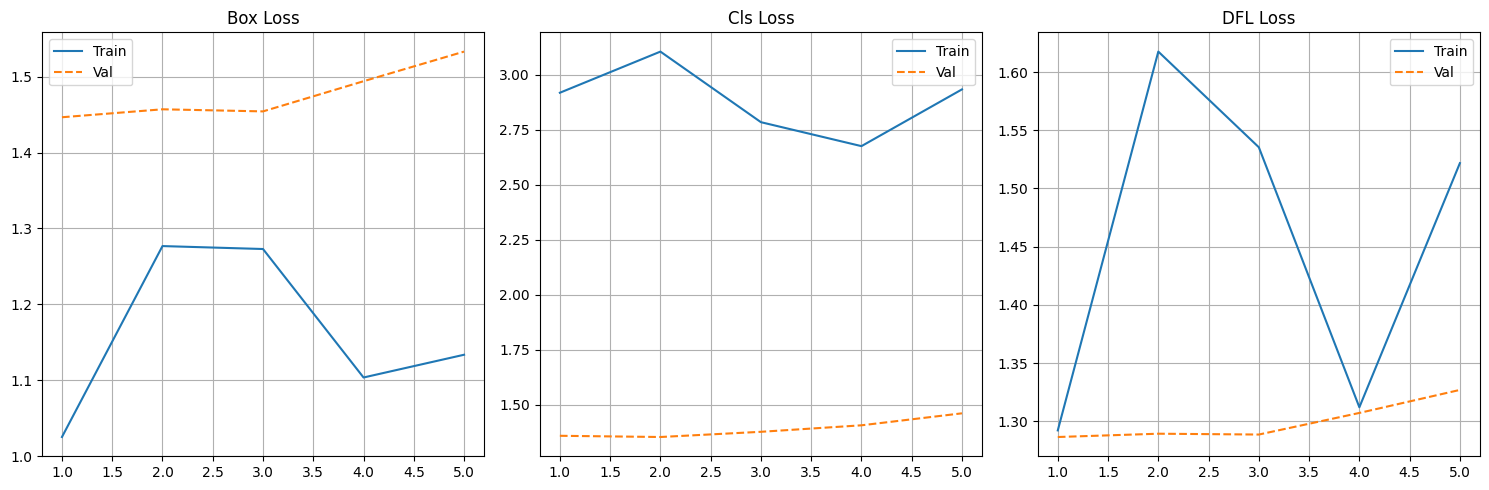

In [12]:
%matplotlib inline

df = pd.read_csv('runs/detect/train/results.csv')
df.columns = df.columns.str.strip()
epochs = df['epoch']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(epochs, df['train/box_loss'], label='Train')
axes[0].plot(epochs, df['val/box_loss'], label='Val', linestyle='--')
axes[0].set_title('Box Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, df['train/cls_loss'], label='Train')
axes[1].plot(epochs, df['val/cls_loss'], label='Val', linestyle='--')
axes[1].set_title('Cls Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs, df['train/dfl_loss'], label='Train')
axes[2].plot(epochs, df['val/dfl_loss'], label='Val', linestyle='--')
axes[2].set_title('DFL Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


### Test

Found 3 image(s) in 'images/'.

Detecting: keyboard.jpg ---

image 1/1 /root/WorkSpace/YOLO/images/keyboard.jpg: 288x640 3 keyboards, 5.5ms
Speed: 10.6ms preprocess, 5.5ms inference, 1.0ms postprocess per image at shape (1, 3, 288, 640)


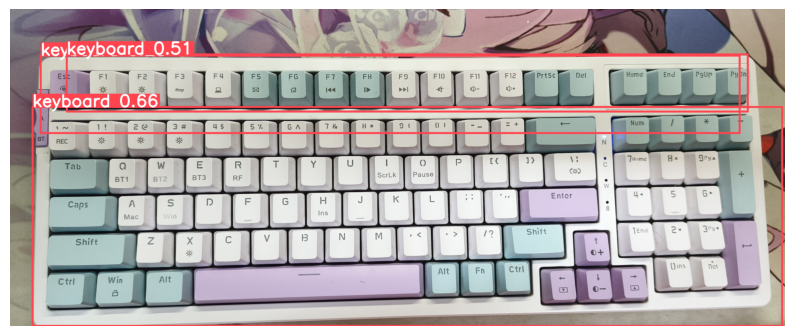


Detecting: mouse.jpg ---

image 1/1 /root/WorkSpace/YOLO/images/mouse.jpg: 480x640 1 mouse, 5.2ms
Speed: 2.4ms preprocess, 5.2ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


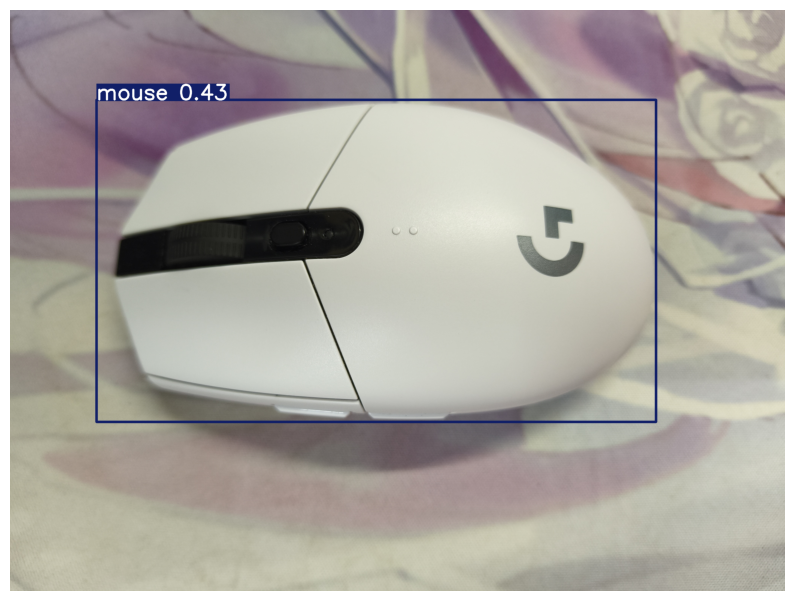


Detecting: suitcase.jpg ---

image 1/1 /root/WorkSpace/YOLO/images/suitcase.jpg: 640x480 1 suitcase, 4.7ms
Speed: 2.2ms preprocess, 4.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


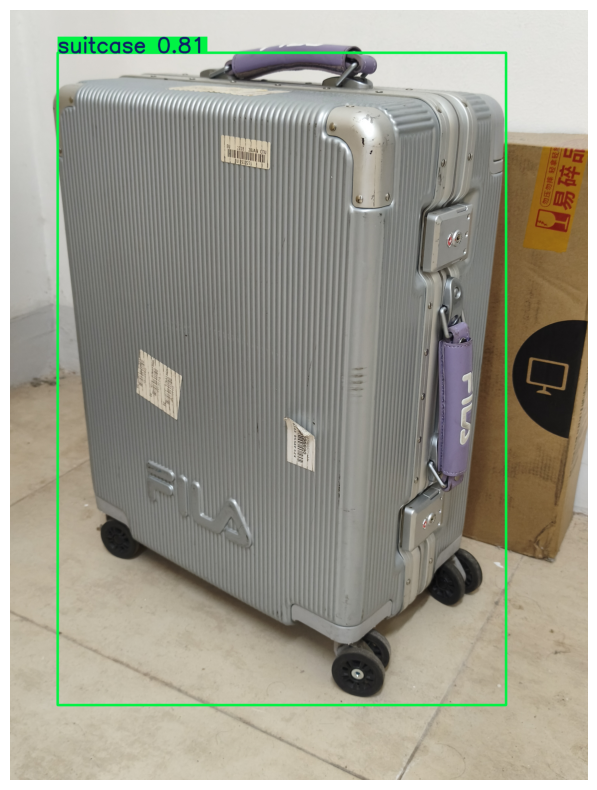

In [14]:
image_dir = "images"


image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]

print(f"Found {len(image_files)} image(s) in '{image_dir}/'.")

for img_name in image_files:
    img_path = os.path.join(image_dir, img_name)
    print(f"\nDetecting: {img_name} ---")

    results = model.predict(img_path, save=False)

    for r in results:
        annotated_frame = r.plot()
        img_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.axis('off') 
        plt.show()